<a href="https://colab.research.google.com/github/Chidera123-collab/Volve_Data_EDA/blob/main/Volve_Data_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Data Cleaning

In [54]:
Volve = pd.read_csv("https://raw.githubusercontent.com/Okwybobby/NDI-Python-Class/refs/heads/main/Volve_Production_Data.csv")
Volve.head()
Volve

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,07-Apr-14,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production
1,08-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production
2,09-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production
3,10-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production
4,11-Apr-14,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,NaN,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,14-Sep-16,15/9-F-5,0.0,NaN,NaN,NaN,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,NaN,production
15630,15-Sep-16,15/9-F-5,0.0,NaN,NaN,NaN,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,NaN,production
15631,16-Sep-16,15/9-F-5,0.0,NaN,NaN,NaN,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,NaN,production
15632,17-Sep-16,15/9-F-5,0.0,NaN,NaN,NaN,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,NaN,production


Cleaning Steps:
Convert Date to datetime,
Check duplicates,
Drop duplicates,


In [3]:
Volve['DATEPRD'] = pd.to_datetime(Volve['DATEPRD'])        #Convert Date to datetime
Volve.duplicated().sum()                                   #Check Duplicates
production_data = Volve[Volve['FLOW_KIND'] == 'production']  #Separate Production and Injection Data
injection_data = Volve[Volve['FLOW_KIND'] == 'injection']


/tmp/ipykernel_3425/1430658915.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Volve['DATEPRD'] = pd.to_datetime(Volve['DATEPRD'])        #Convert Date to datetime


In [4]:
production_data[['BORE_OIL_VOL',   #Handle Missing Production Volumes
               'BORE_GAS_VOL',
               'BORE_WAT_VOL']].isnull().sum()

,0
BORE_OIL_VOL,0
BORE_GAS_VOL,0
BORE_WAT_VOL,0


In [55]:
injection_data['BORE_WI_VOL'].isnull().sum()  # Count missing water injection values

np.int64(782)

In [56]:
Volve['ON_STREAM_HRS'].describe()  # Display descriptive statistics for 'ON_STREAM_HRS'

,ON_STREAM_HRS
count,15349.000000
mean,19.994172
std,8.369911
min,0.000000
25%,24.000000
50%,24.000000
75%,24.000000
max,25.000000


In [57]:
Volve[Volve['ON_STREAM_HRS'] > 24]  # Filter for entries where operating hours exceed 24 (potential anomaly)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
202,26-Oct-14,15/9-F-1 C,25.00,220.958,108.336,184.404,NaN,50.80040,36.554,47.288,7.918,333.0,51385.0,336.0,NaN,production
856,27-Oct-13,15/9-F-11,24.31,256.048,106.207,173.835,18.871,10.38878,82.213,60.018,53.862,1220.0,188361.0,70.0,NaN,production
1218,26-Oct-14,15/9-F-11,25.00,220.579,106.420,167.636,25.464,11.42529,52.943,63.461,24.514,1111.0,171297.0,340.0,NaN,production
2166,26-Oct-08,15/9-F-12,25.00,233.665,106.112,163.381,13.812,47.94442,70.284,75.274,37.889,3837.0,547535.0,13.0,NaN,production
2527,25-Oct-09,15/9-F-12,24.83,261.865,106.783,184.308,10.469,51.15358,77.558,75.845,45.036,4190.0,585516.0,280.0,NaN,production
2891,31-Oct-10,15/9-F-12,25.00,0.000,0.000,52.642,23.158,53.11876,52.642,88.527,20.099,1678.0,248776.0,3676.0,NaN,production
3912,27-Oct-13,15/9-F-12,24.14,0.000,0.000,33.459,14.795,95.09207,33.459,89.322,4.623,281.0,43384.0,4799.0,NaN,production
4274,26-Oct-14,15/9-F-12,25.00,0.000,0.000,32.823,19.162,100.00000,32.823,87.203,4.057,187.0,28884.0,5004.0,NaN,production
5222,26-Oct-08,15/9-F-14,25.00,214.028,105.110,149.515,NaN,43.48696,64.512,78.139,31.849,4609.0,657673.0,2.0,NaN,production
5583,25-Oct-09,15/9-F-14,24.50,241.828,105.789,173.395,0.000,39.83214,68.434,81.803,35.188,3384.0,472845.0,1073.0,NaN,production


<Axes: ylabel='BORE_OIL_VOL'>

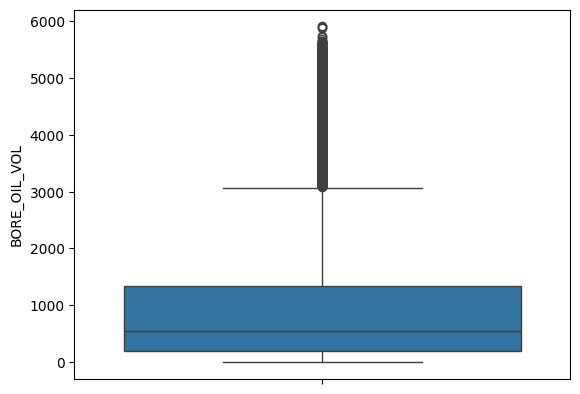

In [58]:
sns.boxplot(data=Volve['BORE_OIL_VOL'])   # Detect Outliers:Black outliers capture initial high flush production; the blue box captures the subsequent drop to stable baseline operations.
# Resources

In [9]:
Q1 = Volve['BORE_OIL_VOL'].quantile(0.25)
Q3 = Volve['BORE_OIL_VOL'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(1154.0)

#Data Understanding

In [10]:
#How many wells are represented in the dataset?

num_wells = Volve['NPD_WELL_BORE_NAME'].nunique()
num_wells

7

In [11]:
# Which wells are production wells and which are injection wells?

production_wells = production_data['NPD_WELL_BORE_NAME'].unique()
injection_wells = injection_data['NPD_WELL_BORE_NAME'].unique()

print("Production Wells:")
for well in production_wells:
    print(f"- {well}")

print("\nInjection Wells:")
for well in injection_wells:
    print(f"- {well}")


Production Wells:
- 15/9-F-1 C
- 15/9-F-11
- 15/9-F-12
- 15/9-F-14
- 15/9-F-15 D
- 15/9-F-5

Injection Wells:
- 15/9-F-4
- 15/9-F-5


In [12]:
#What is the date range covered by the dataset?
min_date = Volve['DATEPRD'].min()
max_date = Volve['DATEPRD'].max()

print(f"Date Range: {min_date} to {max_date}")

Date Range: 2007-09-01 00:00:00 to 2016-12-01 00:00:00


In [13]:
# What is the total oil produced by each well?
total_oil_by_well = Volve.groupby('NPD_WELL_BORE_NAME')['BORE_OIL_VOL'].sum()
display(total_oil_by_well)

,BORE_OIL_VOL
NPD_WELL_BORE_NAME,
15/9-F-1 C,177707.0
15/9-F-11,1147860.0
15/9-F-12,4579620.0
15/9-F-14,3942270.0
15/9-F-15 D,148520.0
15/9-F-4,0.0
15/9-F-5,41163.0


#Production & Injection Analysis

In [59]:
# Calculate and display total oil, gas, and water produced by each well.
total_production_by_well = Volve.groupby('NPD_WELL_BORE_NAME')[['BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']].sum()
display(total_production_by_well)

,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL
NPD_WELL_BORE_NAME,,,
15/9-F-1 C,177707.0,26440916.0,207305.0
15/9-F-11,1147860.0,174310528.0,1090818.0
15/9-F-12,4579620.0,667542296.0,6833353.0
15/9-F-14,3942270.0,578009540.0,7121231.0
15/9-F-15 D,148520.0,22505357.0,52350.0
15/9-F-4,0.0,0.0,0.0
15/9-F-5,41163.0,6561830.0,13536.0


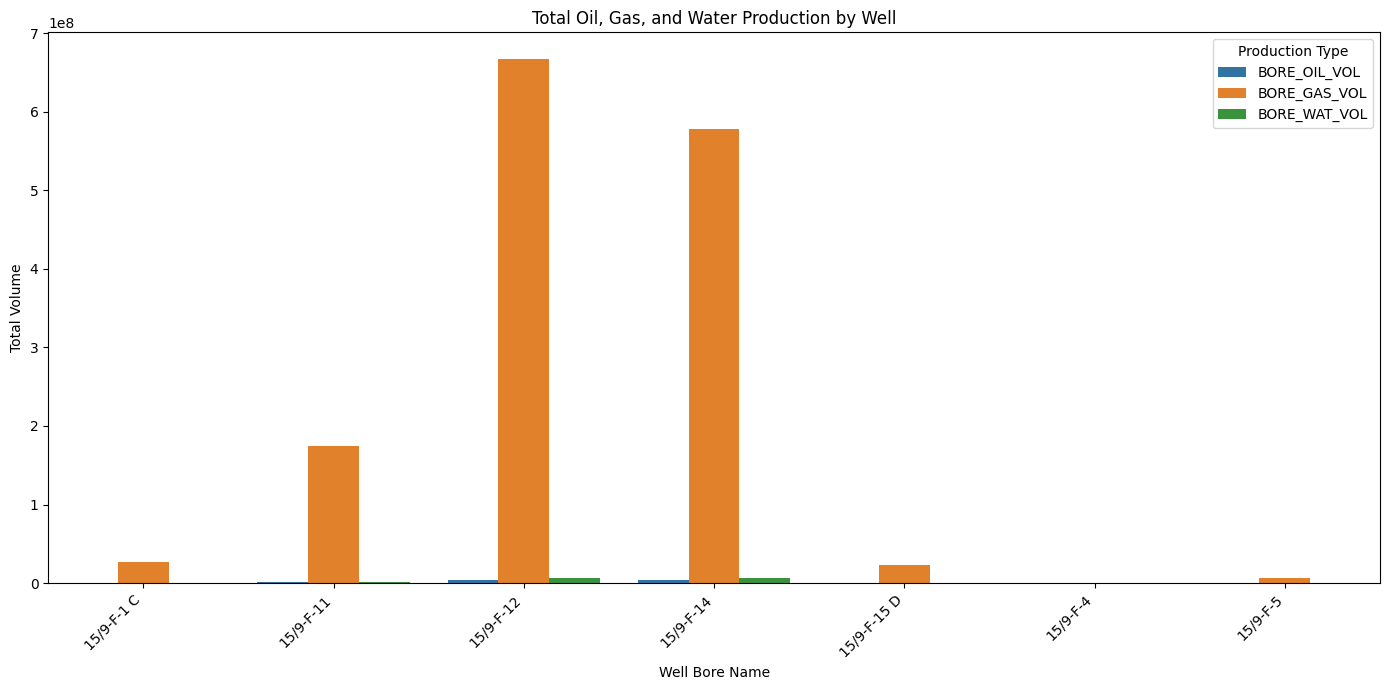

In [61]:
# Plot total oil, gas, and water produced by each well using a bar chart.

import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to make 'NPD_WELL_BORE_NAME' a column for plotting
total_production_df = total_production_by_well.reset_index()

# Melt the DataFrame to long format for easy plotting with seaborn
production_melted = total_production_df.melt(id_vars=['NPD_WELL_BORE_NAME'],
                                             value_vars=['BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL'],
                                             var_name='Production_Type',
                                             value_name='Volume')

plt.figure(figsize=(14, 7))
sns.barplot(x='NPD_WELL_BORE_NAME', y='Volume', hue='Production_Type', data=production_melted)
plt.title('Total Oil, Gas, and Water Production by Well')
plt.xlabel('Well Bore Name')
plt.ylabel('Total Volume')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Production Type')
plt.tight_layout()
plt.show()

,BORE_WI_VOL
NPD_WELL_BORE_NAME,
15/9-F-4,16240712.0
15/9-F-5,14089412.0


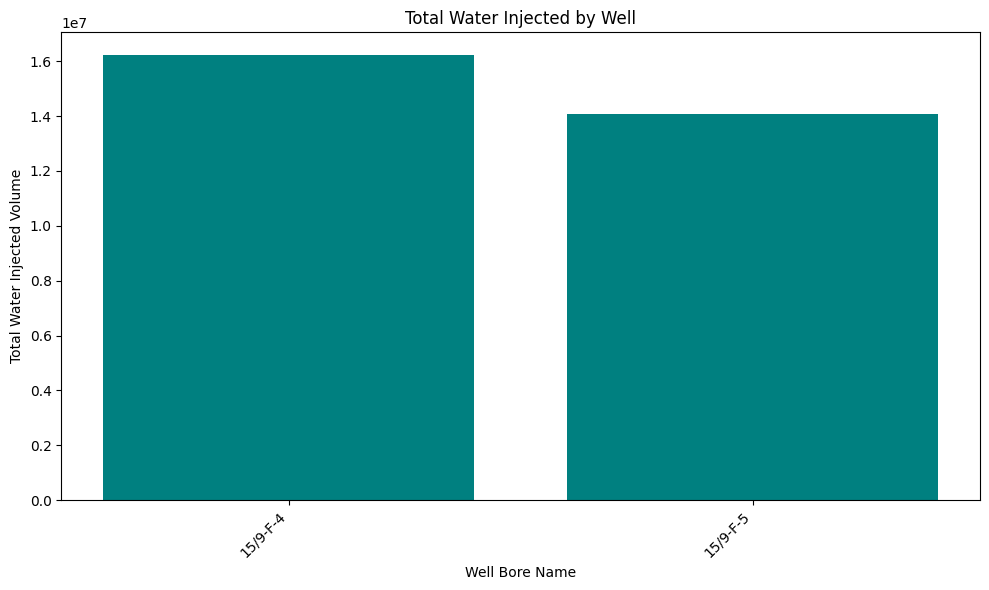

In [62]:
# Calculate and plot total water injected by well.

total_water_injected_by_well = injection_data.groupby('NPD_WELL_BORE_NAME')['BORE_WI_VOL'].sum()
display(total_water_injected_by_well)

# Convert the Series to a DataFrame for easier plotting
total_water_injected_df = total_water_injected_by_well.reset_index()
total_water_injected_df.columns = ['NPD_WELL_BORE_NAME', 'Total_Water_Injected_Vol']

plt.figure(figsize=(10, 6))
plt.bar(total_water_injected_df['NPD_WELL_BORE_NAME'], total_water_injected_df['Total_Water_Injected_Vol'], color='teal')
plt.title('Total Water Injected by Well')
plt.xlabel('Well Bore Name')
plt.ylabel('Total Water Injected Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top-performing wells



In [18]:
# Identify top-performing wells based on total oil production
top_oil_producing_wells = total_oil_by_well.sort_values(ascending=False).head(5)
display(top_oil_producing_wells)

,BORE_OIL_VOL
NPD_WELL_BORE_NAME,
15/9-F-12,4579620.0
15/9-F-14,3942270.0
15/9-F-11,1147860.0
15/9-F-1 C,177707.0
15/9-F-15 D,148520.0


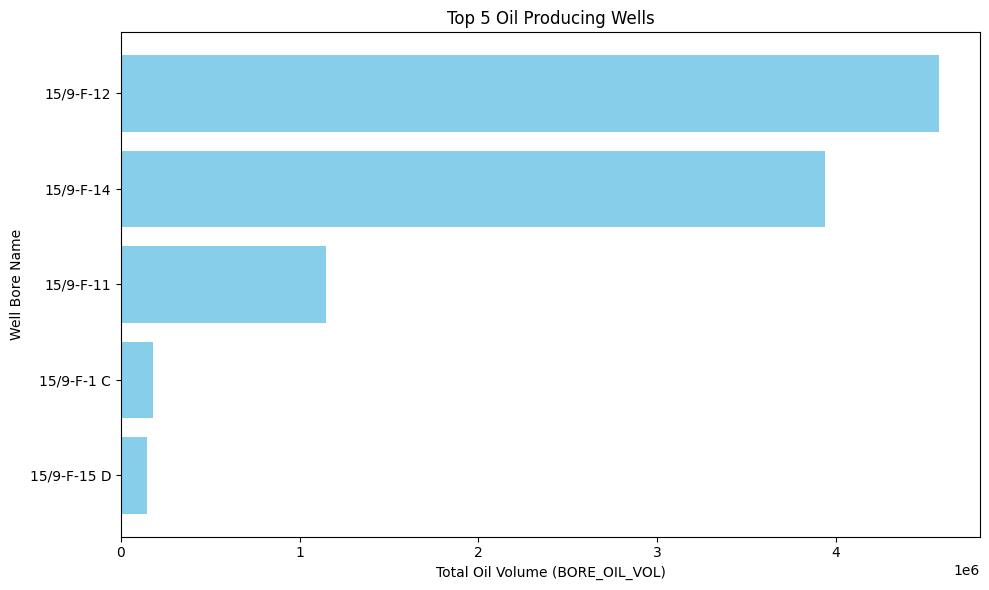

In [63]:
# Plot the top 5 oil-producing wells as a horizontal bar chart.
import matplotlib.pyplot as plt

# Sort for visualization, though it should already be sorted from the previous step
chart_data = top_oil_producing_wells.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(chart_data.index, chart_data.values, color='skyblue')
plt.xlabel('Total Oil Volume (BORE_OIL_VOL)')
plt.ylabel('Well Bore Name')
plt.title('Top 5 Oil Producing Wells')
plt.tight_layout()
plt.show()

#Time-Series Analysis

In [65]:
# Filter production data and convert 'DATEPRD' to datetime for time-series analysis.

production_data = Volve[Volve['FLOW_KIND'] == 'production'].copy()
production_data['DATEPRD'] = pd.to_datetime(production_data['DATEPRD'], format='%d-%b-%y')

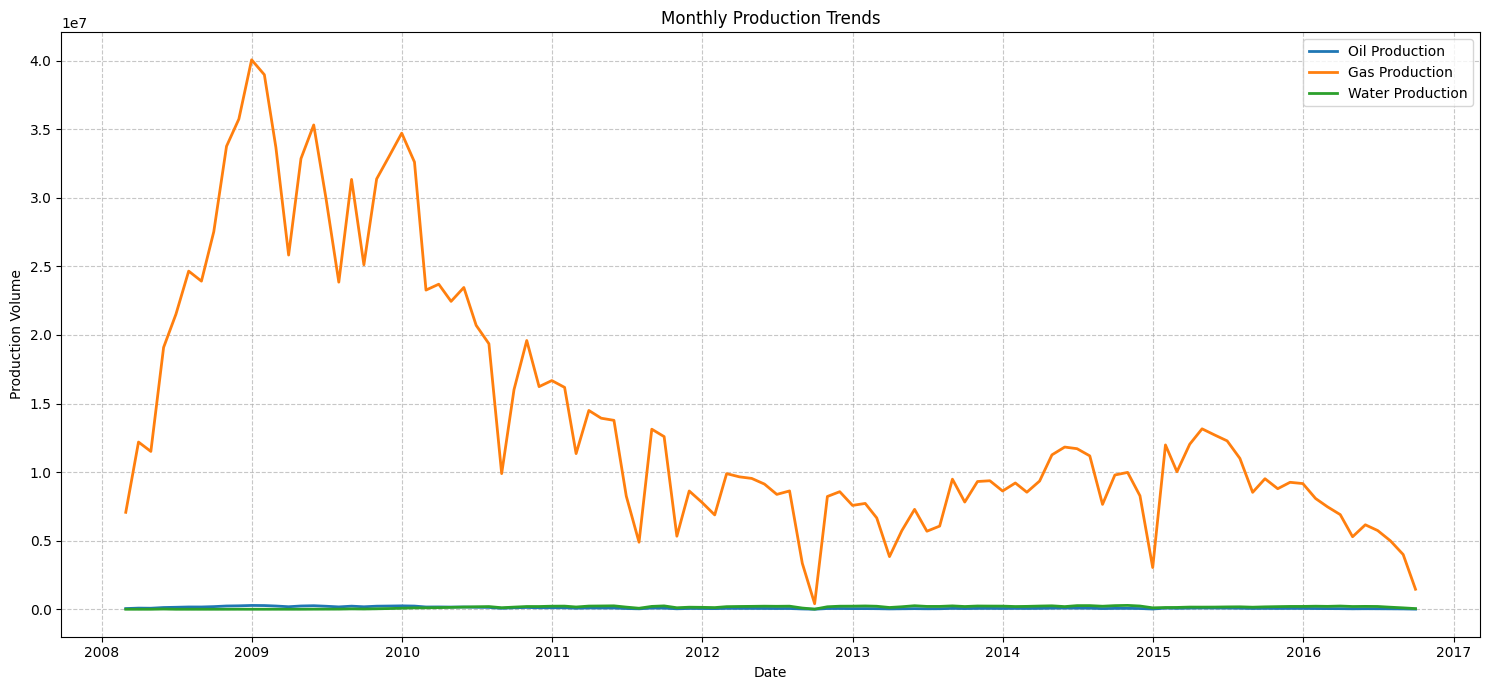

In [66]:
# Calculate and plot monthly production trends for oil, gas, and water.
import matplotlib.pyplot as plt

# Monthly production
monthly_production = (
    production_data
    .groupby(pd.Grouper(key='DATEPRD', freq='ME'))[
        ['BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']
    ]
    .sum()
)

# Plot
plt.figure(figsize=(15,7))

plt.plot(monthly_production.index,
         monthly_production['BORE_OIL_VOL'],
         label='Oil Production',
         linewidth=2)

plt.plot(monthly_production.index,
         monthly_production['BORE_GAS_VOL'],
         label='Gas Production',
         linewidth=2)

plt.plot(monthly_production.index,
         monthly_production['BORE_WAT_VOL'],
         label='Water Production',
         linewidth=2)

plt.title('Monthly Production Trends')
plt.xlabel('Date')
plt.ylabel('Production Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

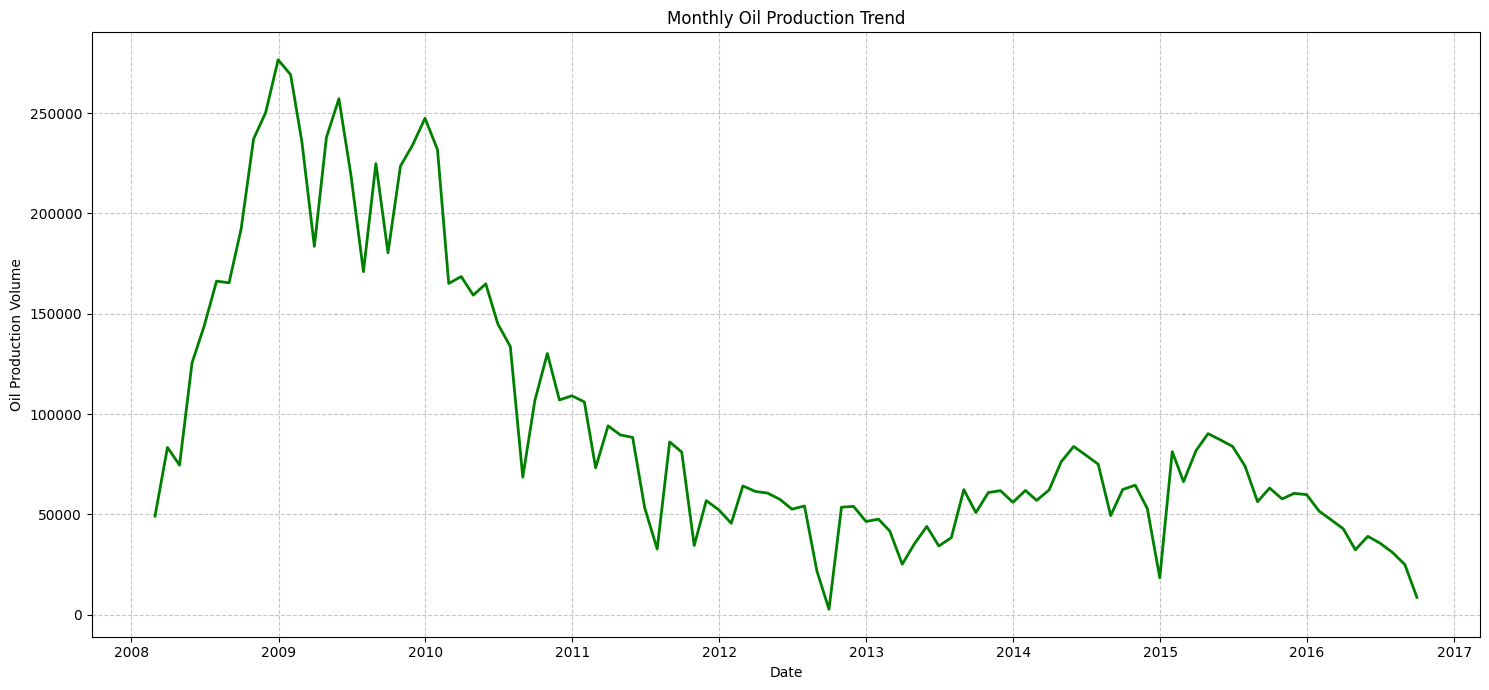

In [67]:
# Calculate and plot the monthly trend of oil production.
monthly_oil = (
    production_data
    .groupby(pd.Grouper(key='DATEPRD', freq='ME'))['BORE_OIL_VOL']
    .sum()
)

plt.figure(figsize=(15,7))

plt.plot(
    monthly_oil.index,
    monthly_oil.values,
    color='green',
    linewidth=2
)

plt.title('Monthly Oil Production Trend')
plt.xlabel('Date')
plt.ylabel('Oil Production Volume')

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

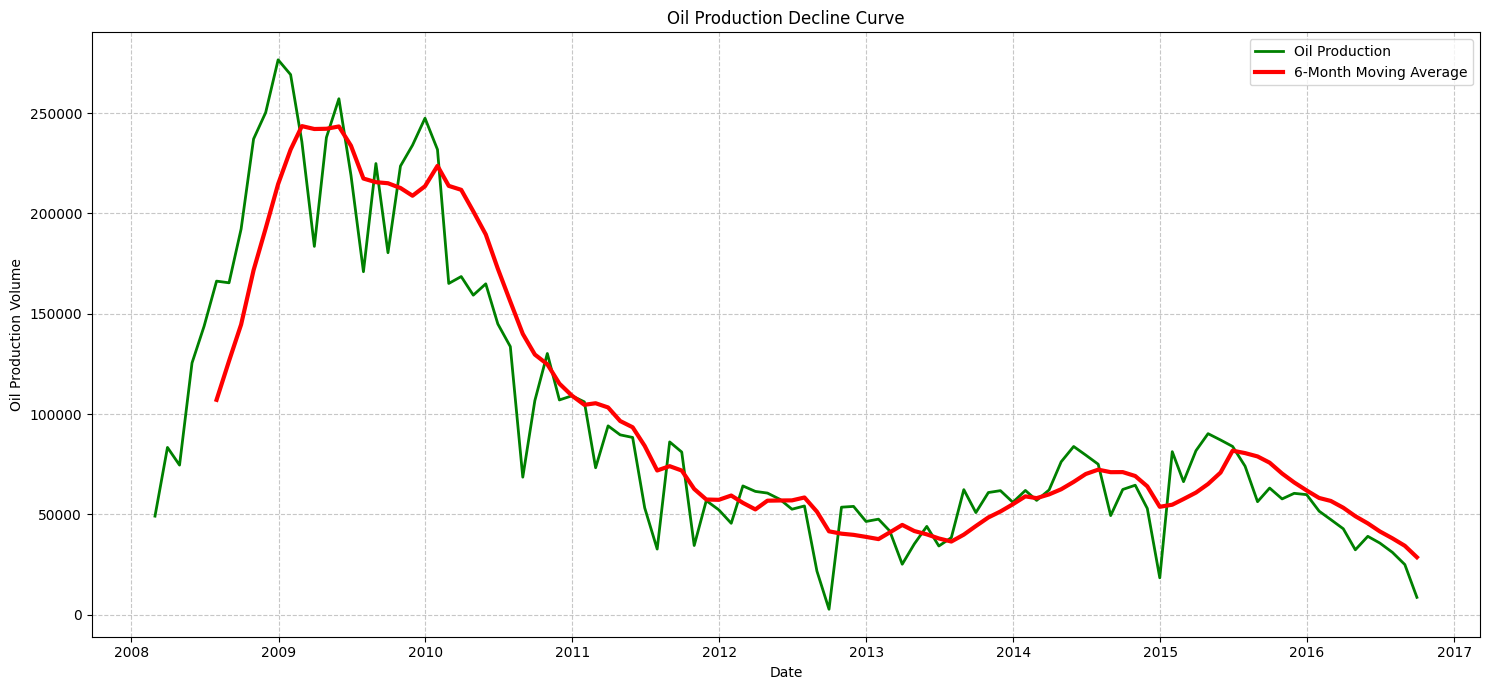

In [68]:
# Visualize the oil production decline curve and its 6-month moving average.
plt.figure(figsize=(15,7))

plt.plot(
    monthly_oil.index,
    monthly_oil.values,
    color='green',
    linewidth=2,
    label='Oil Production'
)

plt.plot(
    monthly_oil.index,
    monthly_oil.rolling(window=6).mean(),
    color='red',
    linewidth=3,
    label='6-Month Moving Average'
)

plt.title('Oil Production Decline Curve')
plt.xlabel('Date')
plt.ylabel('Oil Production Volume')

plt.legend()

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Operational & Reservoir Analysis**

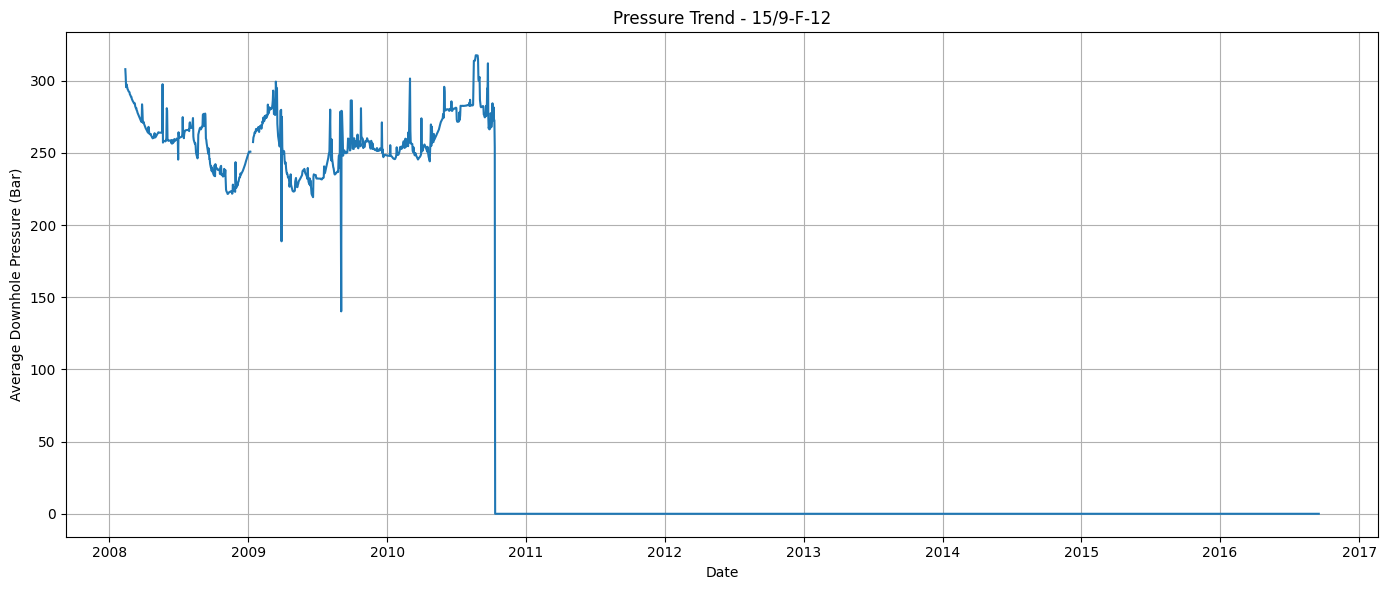

In [70]:
# Plot the pressure trend for a specific well.
top_well = '15/9-F-12'

well_pressure = production_data[
    production_data['NPD_WELL_BORE_NAME'] == top_well
]

plt.figure(figsize=(14,6))

plt.plot(
    well_pressure['DATEPRD'],
    well_pressure['AVG_DOWNHOLE_PRESSURE']
)

plt.title(f'Pressure Trend - {top_well}')
plt.xlabel('Date')
plt.ylabel('Average Downhole Pressure (Bar)')

plt.grid(True)

plt.tight_layout()
plt.show()

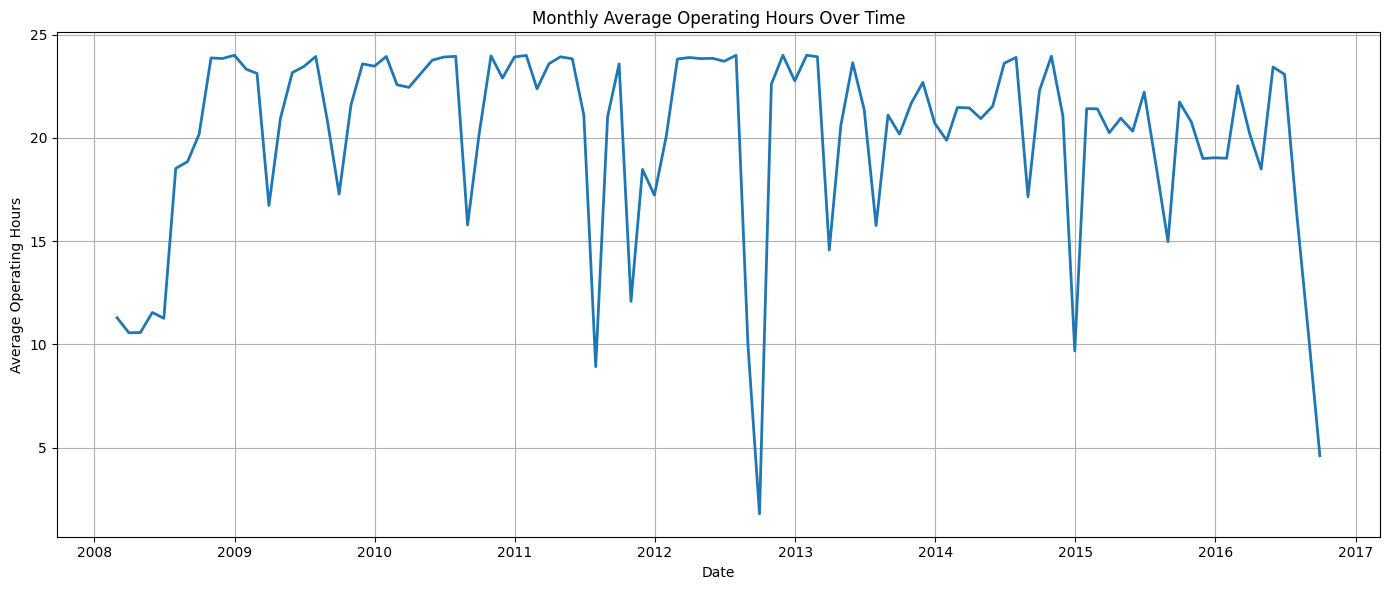

In [71]:
# Calculate and plot the monthly average operating hours for all production wells.
import matplotlib.pyplot as plt

# Calculate monthly average operating hours
monthly_hours = (
    production_data
    .groupby(pd.Grouper(key='DATEPRD', freq='ME'))['ON_STREAM_HRS']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(14,6))

plt.plot(
    monthly_hours['DATEPRD'],
    monthly_hours['ON_STREAM_HRS'],
    linewidth=2
)

plt.title('Monthly Average Operating Hours Over Time')
plt.xlabel('Date')
plt.ylabel('Average Operating Hours')
plt.grid(True)

plt.tight_layout()
plt.show()

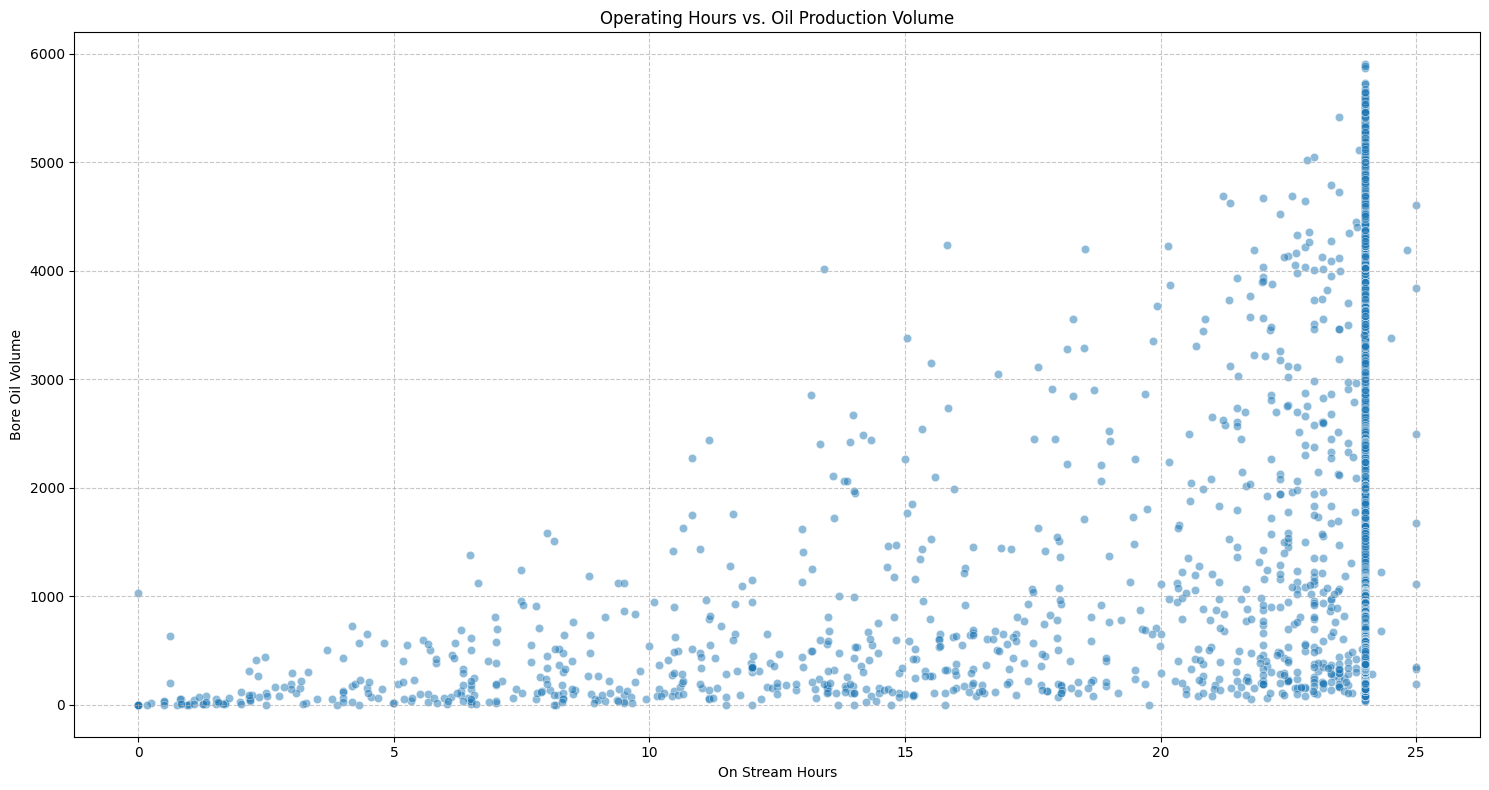

In [72]:
# Visualize the relationship between operating hours and oil production volume.
plt.figure(figsize=(15, 8))
sns.scatterplot(x=Volve['ON_STREAM_HRS'], y=Volve['BORE_OIL_VOL'], alpha=0.5)
plt.title('Operating Hours vs. Oil Production Volume')
plt.xlabel('On Stream Hours')
plt.ylabel('Bore Oil Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This scatter plot visualizes the relationship between the well's operating hours (`ON_STREAM_HRS`) and the volume of oil produced (`BORE_OIL_VOL`).

**Observations from this chart can include:**
*   **Positive Correlation:** You would generally expect to see a positive correlation, meaning that as operating hours increase, oil production volume also tends to increase. Wells that are on stream for longer periods should produce more oil.
*   **Clusters:** Look for clusters of data points. For example, a cluster at `24 ON_STREAM_HRS` with high oil volume would indicate consistent production during full operating days.
*   **Variability:** Observe the spread of oil production for a given number of operating hours. High variability might suggest other factors influencing production, such as choke size, reservoir pressure, or well conditions.
*   **Outliers:** Identify any data points that deviate significantly from the general trend. For instance, a well with very high operating hours but low production, or vice-versa, could be an anomaly worth investigating.

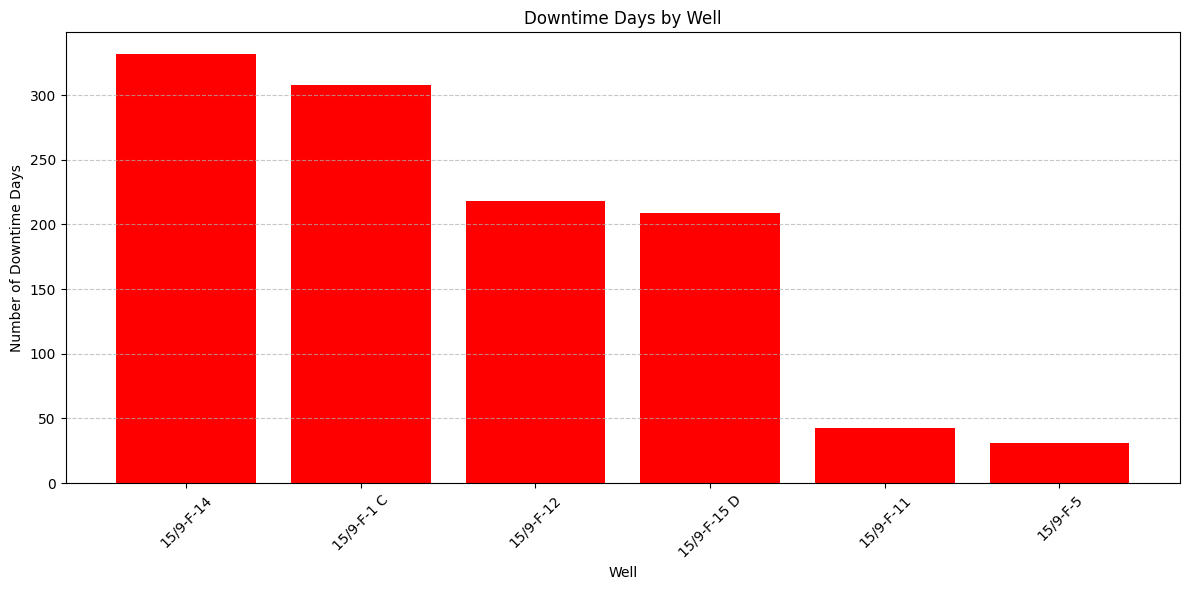

In [73]:
# Calculate and plot the number of downtime days for each well.
downtime = (
    production_data[production_data['ON_STREAM_HRS'] == 0]
    .groupby('NPD_WELL_BORE_NAME')
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    downtime.index,
    downtime.values,
    color='red'
)

plt.title('Downtime Days by Well')
plt.xlabel('Well')
plt.ylabel('Number of Downtime Days')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This chart displays the total number of days each production well was completely offline (operating hours equal to zero). This is crucial for identifying wells with significant downtime, which can indicate operational issues, maintenance needs, or other production interruptions.



# **Correlational and Feature Analysis**

In [74]:
# Select numerical variables and compute their correlation matrix.
correlation_data = production_data[
    [
        'AVG_DOWNHOLE_PRESSURE',
        'AVG_DOWNHOLE_TEMPERATURE',
        'AVG_CHOKE_SIZE_P',
        'ON_STREAM_HRS',
        'BORE_OIL_VOL',
        'BORE_GAS_VOL',
        'BORE_WAT_VOL',
        'BORE_WI_VOL'
    ]
]

# Compute correlation matrix
correlation_matrix = correlation_data.corr()

# Display
display(correlation_matrix)

,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_CHOKE_SIZE_P,ON_STREAM_HRS,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL
AVG_DOWNHOLE_PRESSURE,1.000000,0.967826,-0.262804,-0.003092,0.248573,0.245981,-0.296767,NaN
AVG_DOWNHOLE_TEMPERATURE,0.967826,1.000000,-0.295764,0.105932,0.289820,0.287328,-0.343583,NaN
AVG_CHOKE_SIZE_P,-0.262804,-0.295764,1.000000,0.531331,0.029670,0.039699,0.760294,NaN
ON_STREAM_HRS,-0.003092,0.105932,0.531331,1.000000,0.342030,0.353712,0.405123,NaN
BORE_OIL_VOL,0.248573,0.289820,0.029670,0.342030,1.000000,0.998561,-0.112670,NaN
BORE_GAS_VOL,0.245981,0.287328,0.039699,0.353712,0.998561,1.000000,-0.095591,NaN
BORE_WAT_VOL,-0.296767,-0.343583,0.760294,0.405123,-0.112670,-0.095591,1.000000,NaN
BORE_WI_VOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


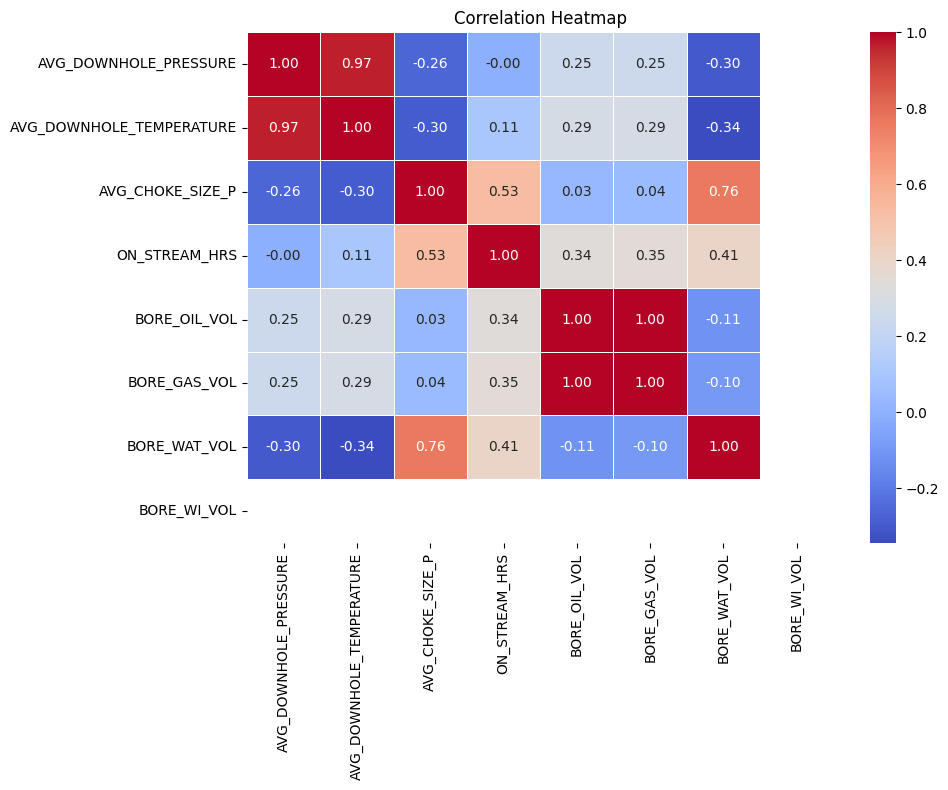

In [76]:
# This chart displays the total number of days each production well was completely offline (operating hours equal to zero).
# This is crucial for identifying wells with significant downtime, which can indicate operational issues, maintenance needs, or other production interruptions.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

This heatmap visualizes the correlation matrix of several numerical variables, including downhole pressure, downhole temperature, choke size, on-stream hours, and oil, gas, water, and water injection volumes.

Colors and Values: The heatmap uses a 'coolwarm' colormap where warm colors (reds) indicate positive correlation, cool colors (blues) indicate negative correlation, and values close to zero (lighter colors) indicate weak or no linear correlation. The numbers within each cell are the correlation coefficients, ranging from -1 to 1.
Interpretation: For instance, you can observe a very strong positive correlation (close to 1.00) between AVG_DOWNHOLE_PRESSURE and AVG_DOWNHOLE_TEMPERATURE, suggesting they tend to increase or decrease together. There's also a strong positive correlation between BORE_OIL_VOL and BORE_GAS_VOL. On the other hand, AVG_CHOKE_SIZE_P shows some negative correlation with downhole pressure and temperature. ON_STREAM_HRS seems to have a positive correlation with oil and gas volumes.

In [77]:
# Identify and display the top correlated pairs from the correlation matrix.
# 'unstack()' reshapes the correlation matrix to a Series of all correlations.
# 'sort_values(ascending=False)' orders them from strongest positive to strongest negative.
# 'corr_pairs < 1' filters out self-correlations (correlation of a variable with itself, which is always 1).
corr_pairs = (
    correlation_matrix
    .unstack()
    .sort_values(ascending=False)
)

# Remove duplicate pairs
corr_pairs = corr_pairs[corr_pairs < 1]

display(corr_pairs.head(10))

,,0
BORE_GAS_VOL,BORE_OIL_VOL,0.998561
BORE_OIL_VOL,BORE_GAS_VOL,0.998561
AVG_DOWNHOLE_TEMPERATURE,AVG_DOWNHOLE_PRESSURE,0.967826
AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,0.967826
BORE_WAT_VOL,AVG_CHOKE_SIZE_P,0.760294
AVG_CHOKE_SIZE_P,BORE_WAT_VOL,0.760294
ON_STREAM_HRS,AVG_CHOKE_SIZE_P,0.531331
AVG_CHOKE_SIZE_P,ON_STREAM_HRS,0.531331
ON_STREAM_HRS,BORE_WAT_VOL,0.405123
BORE_WAT_VOL,ON_STREAM_HRS,0.405123


BORE_GAS_VOL and BORE_OIL_VOL show a very strong positive correlation (0.998561), meaning that as gas production increases, oil production tends to increase significantly as well, and vice-versa.
 This is a common relationship in oil and gas reservoirs.
AVG_DOWNHOLE_TEMPERATURE and AVG_DOWNHOLE_PRESSURE also have a very strong positive correlation (0.967826), indicating they often rise and fall together. This could be due to reservoir characteristics or operational conditions.
BORE_WAT_VOL and AVG_CHOKE_SIZE_P show a strong positive correlation (0.760294). This suggests that a larger choke size might be associated with higher water production.

ON_STREAM_HRS and AVG_CHOKE_SIZE_P have a moderate positive correlation (0.531331), implying that wells operating for longer hours might also be using larger choke sizes.
ON_STREAM_HRS and BORE_WAT_VOL show a positive correlation (0.405123), which is expected as more operating hours would generally lead to more water production.